# 01 — Scoring System Impact on Lineup Optimization

**What you'll learn:**
- How the four built-in scoring systems (Standard, Half-PPR, PPR, custom) change
  each player's fantasy point value
- Which positions gain or lose value when receptions are rewarded
- How the optimizer's optimal lineup shifts across scoring systems
- How to define a custom scoring rule and see its effect

**Prerequisites:** FFPy installed (`uv sync`). No database needed.

## Setup

This notebook uses FFPy's optimizer and scoring modules. No database required —
we construct sample players in-memory.

```python
# Run this cell to install analysis deps (first time only)
# !uv sync --group analysis
```

## Imports

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Ensure ffpy is importable (works from notebooks/ dir)
_repo = Path.cwd()
while not (_repo / "pyproject.toml").exists() and _repo.parent != _repo:
    _repo = _repo.parent
sys.path.insert(0, str(_repo / "src"))

from ffpy.optimizer import LineupOptimizer, Player, RosterConstraints
from ffpy.scoring import ScoringConfig, calculate_fantasy_points

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

## Data: Sample Player Stats

In [2]:
# ── Sample players with detailed stat projections ──────────────────────
# Each dict: positional stats that ScoringConfig.calculate_fantasy_points reads.
sample_stats = [
    # ── QBs ──
    {
        "name": "Josh Allen",
        "position": "QB",
        "team": "BUF",
        "passing_yards": 285,
        "passing_tds": 2.4,
        "interceptions": 0.7,
        "rushing_yards": 45,
        "rushing_tds": 0.5,
        "receiving_yards": 0,
        "receptions": 0,
        "receiving_tds": 0,
    },
    {
        "name": "Patrick Mahomes",
        "position": "QB",
        "team": "KC",
        "passing_yards": 310,
        "passing_tds": 2.8,
        "interceptions": 0.6,
        "rushing_yards": 20,
        "rushing_tds": 0.2,
        "receiving_yards": 0,
        "receptions": 0,
        "receiving_tds": 0,
    },
    {
        "name": "Lamar Jackson",
        "position": "QB",
        "team": "BAL",
        "passing_yards": 235,
        "passing_tds": 1.8,
        "interceptions": 0.8,
        "rushing_yards": 70,
        "rushing_tds": 0.6,
        "receiving_yards": 0,
        "receptions": 0,
        "receiving_tds": 0,
    },
    {
        "name": "Jalen Hurts",
        "position": "QB",
        "team": "PHI",
        "passing_yards": 225,
        "passing_tds": 1.7,
        "interceptions": 0.6,
        "rushing_yards": 55,
        "rushing_tds": 0.7,
        "receiving_yards": 0,
        "receptions": 0,
        "receiving_tds": 0,
    },
    {
        "name": "Joe Burrow",
        "position": "QB",
        "team": "CIN",
        "passing_yards": 290,
        "passing_tds": 2.5,
        "interceptions": 0.9,
        "rushing_yards": 10,
        "rushing_tds": 0.1,
        "receiving_yards": 0,
        "receptions": 0,
        "receiving_tds": 0,
    },
    # ── RBs ──
    {
        "name": "Christian McCaffrey",
        "position": "RB",
        "team": "SF",
        "passing_yards": 0,
        "passing_tds": 0,
        "interceptions": 0,
        "rushing_yards": 85,
        "rushing_tds": 0.8,
        "receiving_yards": 45,
        "receptions": 4.5,
        "receiving_tds": 0.2,
    },
    {
        "name": "Bijan Robinson",
        "position": "RB",
        "team": "ATL",
        "passing_yards": 0,
        "passing_tds": 0,
        "interceptions": 0,
        "rushing_yards": 75,
        "rushing_tds": 0.6,
        "receiving_yards": 35,
        "receptions": 3.0,
        "receiving_tds": 0.1,
    },
    {
        "name": "Saquon Barkley",
        "position": "RB",
        "team": "PHI",
        "passing_yards": 0,
        "passing_tds": 0,
        "interceptions": 0,
        "rushing_yards": 80,
        "rushing_tds": 0.7,
        "receiving_yards": 30,
        "receptions": 2.5,
        "receiving_tds": 0.1,
    },
    {
        "name": "Austin Ekeler",
        "position": "RB",
        "team": "WAS",
        "passing_yards": 0,
        "passing_tds": 0,
        "interceptions": 0,
        "rushing_yards": 55,
        "rushing_tds": 0.4,
        "receiving_yards": 50,
        "receptions": 4.0,
        "receiving_tds": 0.2,
    },
    {
        "name": "James Cook",
        "position": "RB",
        "team": "BUF",
        "passing_yards": 0,
        "passing_tds": 0,
        "interceptions": 0,
        "rushing_yards": 65,
        "rushing_tds": 0.5,
        "receiving_yards": 20,
        "receptions": 2.0,
        "receiving_tds": 0.1,
    },
    # ── WRs ──
    {
        "name": "Tyreek Hill",
        "position": "WR",
        "team": "MIA",
        "passing_yards": 0,
        "passing_tds": 0,
        "interceptions": 0,
        "rushing_yards": 5,
        "rushing_tds": 0.0,
        "receiving_yards": 95,
        "receptions": 6.5,
        "receiving_tds": 0.8,
    },
    {
        "name": "CeeDee Lamb",
        "position": "WR",
        "team": "DAL",
        "passing_yards": 0,
        "passing_tds": 0,
        "interceptions": 0,
        "rushing_yards": 5,
        "rushing_tds": 0.0,
        "receiving_yards": 90,
        "receptions": 6.0,
        "receiving_tds": 0.6,
    },
    {
        "name": "Justin Jefferson",
        "position": "WR",
        "team": "MIN",
        "passing_yards": 0,
        "passing_tds": 0,
        "interceptions": 0,
        "rushing_yards": 0,
        "rushing_tds": 0.0,
        "receiving_yards": 85,
        "receptions": 5.5,
        "receiving_tds": 0.5,
    },
    {
        "name": "Amon-Ra St. Brown",
        "position": "WR",
        "team": "DET",
        "passing_yards": 0,
        "passing_tds": 0,
        "interceptions": 0,
        "rushing_yards": 0,
        "rushing_tds": 0.0,
        "receiving_yards": 80,
        "receptions": 6.0,
        "receiving_tds": 0.5,
    },
    {
        "name": "Stefon Diggs",
        "position": "WR",
        "team": "HOU",
        "passing_yards": 0,
        "passing_tds": 0,
        "interceptions": 0,
        "rushing_yards": 0,
        "rushing_tds": 0.0,
        "receiving_yards": 70,
        "receptions": 5.0,
        "receiving_tds": 0.4,
    },
    # ── TEs ──
    {
        "name": "Travis Kelce",
        "position": "TE",
        "team": "KC",
        "passing_yards": 0,
        "passing_tds": 0,
        "interceptions": 0,
        "rushing_yards": 0,
        "rushing_tds": 0.0,
        "receiving_yards": 65,
        "receptions": 4.5,
        "receiving_tds": 0.5,
    },
    {
        "name": "Mark Andrews",
        "position": "TE",
        "team": "BAL",
        "passing_yards": 0,
        "passing_tds": 0,
        "interceptions": 0,
        "rushing_yards": 0,
        "rushing_tds": 0.0,
        "receiving_yards": 55,
        "receptions": 4.0,
        "receiving_tds": 0.4,
    },
    {
        "name": "George Kittle",
        "position": "TE",
        "team": "SF",
        "passing_yards": 0,
        "passing_tds": 0,
        "interceptions": 0,
        "rushing_yards": 0,
        "rushing_tds": 0.0,
        "receiving_yards": 60,
        "receptions": 3.5,
        "receiving_tds": 0.3,
    },
    # ── K ──
    {
        "name": "Justin Tucker",
        "position": "K",
        "team": "BAL",
        "passing_yards": 0,
        "passing_tds": 0,
        "interceptions": 0,
        "rushing_yards": 0,
        "rushing_tds": 0.0,
        "receiving_yards": 0,
        "receptions": 0,
        "receiving_tds": 0,
    },
    # ── DST ──
    {
        "name": "49ers DST",
        "position": "DST",
        "team": "SF",
        "passing_yards": 0,
        "passing_tds": 0,
        "interceptions": 0,
        "rushing_yards": 0,
        "rushing_tds": 0.0,
        "receiving_yards": 0,
        "receptions": 0,
        "receiving_tds": 0,
    },
]

### 1. Define the Scoring Systems

FFPy ships with four presets. Let's list their key difference —
the `reception_points` field:

In [3]:
# Create the four scoring systems
systems = {
    "Standard": ScoringConfig.standard(),
    "Half-PPR": ScoringConfig.half_ppr(),
    "PPR": ScoringConfig.ppr(),
}

# Show the one parameter that changes
rows = []
for name, cfg in systems.items():
    rows.append({"System": name, "Reception Points": cfg.reception_points})
pd.DataFrame(rows)

,System,Reception Points
0,Standard,0.0
1,Half-PPR,0.5
2,PPR,1.0


### 2. Compute Fantasy Points Per Player Per System

We use `calculate_fantasy_points(stats, config)` for every player × system pair.

In [4]:
points_table = []
for p in sample_stats:
    for sys_name, config in systems.items():
        pts = calculate_fantasy_points(p, config)
        points_table.append(
            {
                "player": p["name"],
                "position": p["position"],
                "team": p["team"],
                "system": sys_name,
                "fantasy_points": round(pts, 1),
            }
        )

df_pts = pd.DataFrame(points_table)
df_pts.head(12)

,player,position,team,system,fantasy_points
0,Josh Allen,QB,BUF,Standard,27.1
1,Josh Allen,QB,BUF,Half-PPR,27.1
2,Josh Allen,QB,BUF,PPR,27.1
3,Patrick Mahomes,QB,KC,Standard,25.6
4,Patrick Mahomes,QB,KC,Half-PPR,25.6
5,Patrick Mahomes,QB,KC,PPR,25.6
6,Lamar Jackson,QB,BAL,Standard,25.6
7,Lamar Jackson,QB,BAL,Half-PPR,25.6
8,Lamar Jackson,QB,BAL,PPR,25.6
9,Jalen Hurts,QB,PHI,Standard,24.3


### 3. Visualise: Who Gains from PPR?

UFuncTypeError: ufunc 'add' did not contain a loop with signature matching types (dtype('<U2'), dtype('float64')) -> None

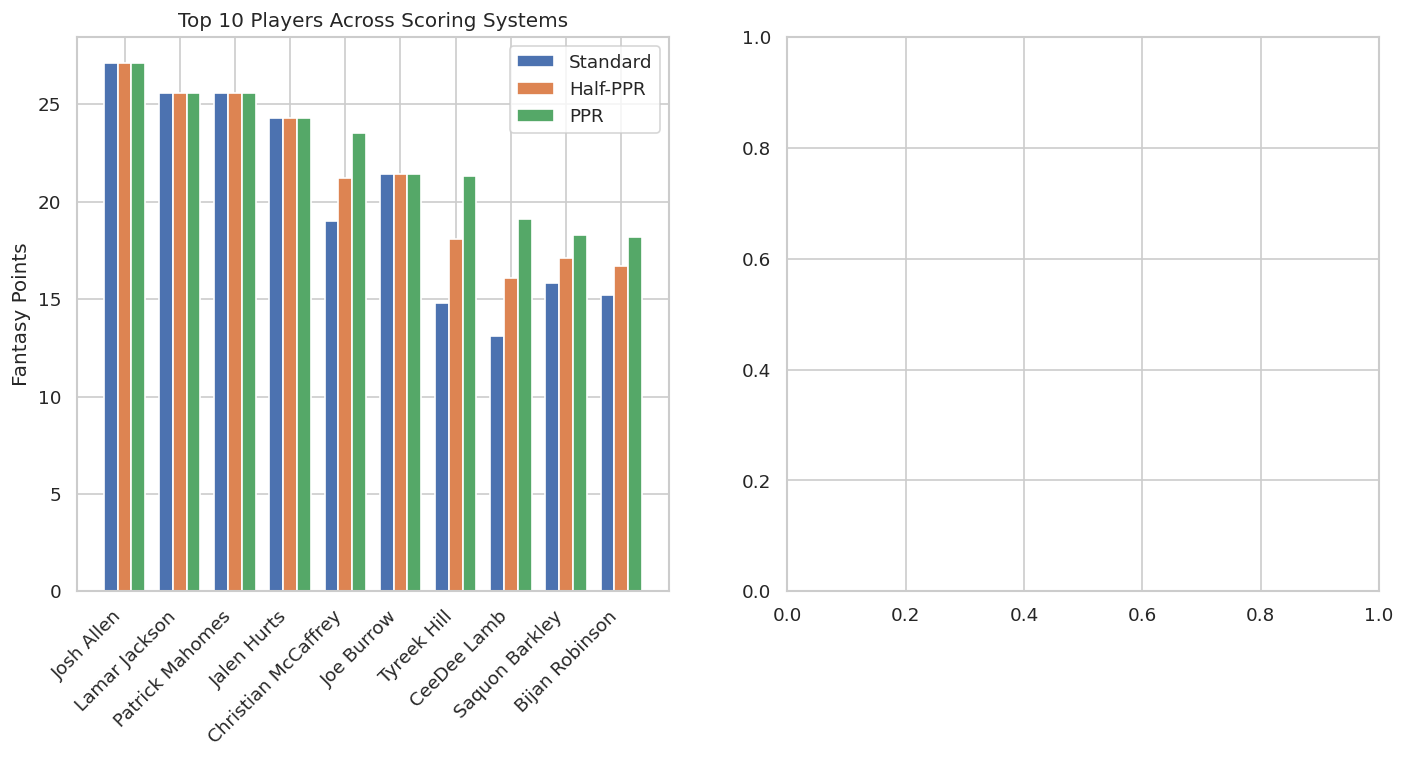

In [5]:
# Pivot: one row per player, columns per system
pivot = df_pts.pivot_table(
    index=["player", "position", "team"],
    columns="system",
    values="fantasy_points",
).reset_index()

# Sort by PPR (highest first)
pivot = pivot.sort_values("PPR", ascending=False)

# Delta column
pivot["PPR_Bonus"] = pivot["PPR"] - pivot["Standard"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: side-by-side bars for top 10 PPR scorers
top10 = pivot.head(10)
x = range(len(top10))
w = 0.25
for i, sys_name in enumerate(["Standard", "Half-PPR", "PPR"]):
    axes[0].bar(
        [xi + i * w for xi in x],
        top10[sys_name],
        width=w,
        label=sys_name,
    )
axes[0].set_xticks([xi + w for xi in x])
axes[0].set_xticklabels(top10["player"], rotation=45, ha="right")
axes[0].set_ylabel("Fantasy Points")
axes[0].set_title("Top 10 Players Across Scoring Systems")
axes[0].legend()

# Right: PPR bonus by position
# Spread the jitter for visibility
rng = np.random.default_rng(42)
for pos, color in [("QB", "#1f77b4"), ("RB", "#ff7f0e"), ("WR", "#2ca02c"), ("TE", "#d62728")]:
    subset = pivot[pivot["position"] == pos]
    axes[1].scatter(
        [pos] * len(subset) + rng.uniform(-0.15, 0.15, len(subset)),
        subset["PPR_Bonus"],
        color=color,
        alpha=0.7,
        s=60,
    )

axes[1].axhline(0, color="grey", linestyle="--", linewidth=0.8)
axes[1].set_ylabel("PPR Bonus (PPR − Standard)")
axes[1].set_title("Which Positions Gain from PPR?")

plt.tight_layout()
plt.show()

**Observation:** WRs and pass-catching RBs see the largest PPR bonus because
volume receptions directly add points. QBs are almost untouched (they rarely
receive passes). TEs with high target volume also get a nice boost.


### 4. Optimise a Lineup Under Each Scoring System

In [ ]:
def build_players(stats_list, config):
    """Convert stat dicts → Player objects with system-appropriate projected_points."""
    players = []
    for s in stats_list:
        pts = calculate_fantasy_points(s, config)
        players.append(
            Player(
                name=s["name"],
                position=s["position"],
                team=s["team"],
                projected_points=pts,
            )
        )
    return players


constraints = RosterConstraints.standard()

results = {}
for sys_name, config in systems.items():
    pool = build_players(sample_stats, config)
    opt = LineupOptimizer(constraints)
    res = opt.optimize(pool)
    results[sys_name] = res

# Display side-by-side
print(f"{'System':<12} {'Total':>6} {'Starters':>9} {'Top Bench':>25}")
print("-" * 55)
for sys_name, res in results.items():
    top = res.bench[0].name if res.bench else "—"
    print(f"{sys_name:<12} {res.total_points:>6.1f} {len(res.starters):>4}  {'':>5} {top:<25}")

### 5. Compare the Actual Lineups

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, (sys_name, config) in enumerate(systems.items()):
    res = results[sys_name]
    by_pos = res.get_starters_by_position()
    ax = axes[idx]

    y = 0
    for pos in ["QB", "RB", "WR", "TE", "K", "DST"]:
        for pl in by_pos.get(pos, []):
            ax.barh(y, pl.projected_points, height=0.6, label=pos if y == 0 else "")
            ax.text(pl.projected_points + 0.3, y, pl.name, va="center", fontsize=8)
            y += 1

    ax.set_yticks([])
    ax.set_xlabel("Projected Points")
    ax.set_title(f"{sys_name} — {res.total_points:.1f} total")
    if idx == 0:
        ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

### 6. Try a Custom Scoring Rule

What if your league rewards big plays? Let's create a **Big-Play Bonus** system
that adds +1 point for 40+ yard TDs. The `ScoringConfig` supports a
`bonus_settings` dict for this:

In [ ]:
big_play = ScoringConfig(
    name="Big Play Bonus",
    reception_points=0.5,  # Half-PPR base
    bonus_settings={"passing_td_40_plus": 1.0, "rushing_td_40_plus": 1.0},
)

# For simplicity, we'll approximate the bonus by assuming a fraction of TDs
# are "long". In a real app the projections would include this flag.
import copy

custom_stats = copy.deepcopy(sample_stats)
for p in custom_stats:
    # Assume 20% of TDs are 40+ yard plays
    long_tds = p.get("passing_tds", 0) * 0.2 + p.get("rushing_tds", 0) * 0.2 + p.get("receiving_tds", 0) * 0.2
    bonus = long_tds * 1.0  # +1 per big-play TD
    p["bonus"] = round(bonus, 1)

# Recalculate with bonus baked into projected_points
pool_big = []
for s in custom_stats:
    base = calculate_fantasy_points(s, big_play)
    pool_big.append(
        Player(
            name=s["name"],
            position=s["position"],
            team=s["team"],
            projected_points=round(base + s.get("bonus", 0), 1),
        )
    )

opt_big = LineupOptimizer(RosterConstraints.standard())
res_big = opt_big.optimize(pool_big)

print("=== Big-Play Bonus League ===")
print(opt_big.analyze_lineup(res_big))

### Key Takeaways

1. **Scoring rules directly change player rankings** — a PPR league values
   pass-catching RBs and slot WRs more than a Standard league.
2. **The optimizer responds to those changes** — the optimal lineup shifts when
   reception_points changes.
3. **Custom bonuses are easy to model** — any rule that can be expressed as a
   per-player stat adjustment integrates cleanly with the optimizer.
4. **For learning:** always check which scoring system your league uses before
   trusting an optimizer's output. Run it with your league's exact config.


---
*Notebook generated by `scripts/generate_optimization_notebooks.py`.*
